In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 61.3 MB/s eta 0:00:00


In [2]:
# 필요 라이브러리 임포트
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
CUDA available: True


In [3]:
# 데이터 경로 설정 및 확인
DATA_DIR = "/content/drive/MyDrive/AI Health care 실습파일/MOLI/Data"  # 데이터 위치

# 전체 파일 목록 확인
for folder in ["response", "SNA_binary", "CNA_binary", "exprs_homogenized"]:
    path = os.path.join(DATA_DIR, folder)
    if os.path.exists(path):
        files = os.listdir(path)
        print(f"\n📁 {folder}/")
        for f in files:  # 처음 5개만 출력
            print(f"   - {f}")
    else:
        print(f"❌ {folder} 폴더를 찾을 수 없음: {path}")


📁 response/
   - GSE18864_response.Cisplatin.tsv
   - GSE25065_response.Docetaxel.tsv
   - GSE25065_response.Paclitaxel.tsv
   - GSE33072_response.Erlotinib.tsv
   - GSE9782-GPL96_response.Bortezomib.tsv
   - GSE9782-GPL97_response.Bortezomib.tsv
   - TCGA_pretraining_samples.with_multi-OMICS.txt
   - TCGA_response.Docetaxel.tsv
   - TCGA_response.Cisplatin.tsv
   - TCGA_response.Erlotinib.tsv
   - TCGA_response.Tamoxifen.tsv
   - TCGA_response.Cetuximab.tsv
   - TCGA_response.Paclitaxel.tsv
   - TCGA_response.Gemcitabine.tsv
   - TCGA_response.Gefitinib.tsv
   - CCLE_response.Paclitaxel.tsv
   - CCLE_response.Erlotinib.tsv
   - CCLE_response.Lapatinib.tsv
   - CCLE_response.ZD-6474.tsv
   - PDX_response.multi-OMICS.Cetuximab.tsv
   - PDX_response.multi-OMICS.Gemcitabine.tsv
   - PDX_response.multi-OMICS.Erlotinib.tsv
   - PDX_response.multi-OMICS.5-Fluorouracil.tsv
   - PDX_response.multi-OMICS.Paclitaxel.tsv
   - GDSC_response.Cisplatin.tsv
   - GDSC_response.Cetuximab.tsv
   - GDSC

## 데이터 구조
```
파일명 패턴 해석:
GDSC_exprs.Cisplatin.eb_with.GSE18864_exprs.Cisplatin.tsv
│              │              │
│              │              └── Validation 데이터 (GSE18864 = TCGA Cisplatin 환자)
│              └── 약물 이름
└── Training 데이터 (GDSC 암세포주)

"eb_with" = empirical Bayes batch correction
→ 서로 다른 플랫폼(Microarray vs RNA-seq)을
  같은 scale로 맞춘 것 (논문 2.4.1절)

## 1. GDSC vs PDX  

GDSC (Genomics of Drug Sensitivity in Cancer)
- 실제 암환자 ❌
- 암세포주 (Cell Line) ✅
  
  → 암환자에서 떼어낸 암세포를 실험실 배양접시에서 키운 것  
  → 1,000여 종의 암세포주 x 265가지 약물 반응 데이터

- 우리 프로젝트에서 역할: 모델 학습(Training)용

PDX (Patient-Derived Xenograft)
- 실제 암환자 ✅ (간접적으로)
- 마우스 모델 ✅  
→ 암환자 종양을 떼어내서 면역결핍 마우스에 이식한 것  
→ 세포주보다 실제 환자에 훨씬 가까움

- 우리 프로젝트에서 역할: 외부 검증(Validation)용  
       ↑  
       이게 논문의 핵심 기여  
       "실험실 데이터로 학습 → 실제 생체 모델에서도 작동하는가?"

In [4]:
# ======================================================
# 1) Cetuximab 데이터 로딩
# ======================================================
DATA_DIR = "/content/drive/MyDrive/AI Health care 실습파일/MOLI/Data"

# 1-1) 경로 정의
EXPR_DIR = os.path.join(DATA_DIR, "exprs_homogenized")
MUT_DIR  = os.path.join(DATA_DIR, "SNA_binary")
CNA_DIR  = os.path.join(DATA_DIR, "CNA_binary")
RESP_DIR = os.path.join(DATA_DIR, "response")

# 1-2) Train 데이터 (GDSC)
train_expr = pd.read_csv(os.path.join(EXPR_DIR, "GDSC_exprs.Cetuximab.eb_with.PDX_exprs.Cetuximab.tsv"),
                         sep="\t", index_col=0, decimal=",")
train_mut  = pd.read_csv(os.path.join(MUT_DIR,  "GDSC_mutations.Cetuximab.tsv"),
                         sep="\t", index_col=0)
train_cna  = pd.read_csv(os.path.join(CNA_DIR,  "GDSC_CNA.Cetuximab.tsv"),
                         sep="\t", index_col=0)
train_resp = pd.read_csv(os.path.join(RESP_DIR, "GDSC_response.Cetuximab.tsv"),
                         sep="\t", index_col=0)

# 1-3) Validation 데이터 (PDX)
val_expr = pd.read_csv(os.path.join(EXPR_DIR, "PDX_exprs.Cetuximab.eb_with.GDSC_exprs.Cetuximab.tsv"),
                       sep="\t", index_col=0, decimal=",")
val_mut  = pd.read_csv(os.path.join(MUT_DIR,  "PDX_mutations.Cetuximab.tsv"),
                       sep="\t", index_col=0)
val_cna  = pd.read_csv(os.path.join(CNA_DIR,  "PDX_CNA.Cetuximab.tsv"),
                       sep="\t", index_col=0)
val_resp = pd.read_csv(os.path.join(RESP_DIR, "PDX_response.multi-OMICS.Cetuximab.tsv"),
                       sep="\t", index_col=0)

# 1-4) Validation 데이터 (TCGA)
TCGA_expr = pd.read_csv(os.path.join(EXPR_DIR, "TCGA_exprs.Cetuximab.eb_with.GDSC_exprs.Cetuximab.tsv"),
                        sep="\t", index_col=0, decimal=",")
TCGA_mut  = pd.read_csv(os.path.join(MUT_DIR, "TCGA_mutations.Cetuximab.tsv"),
                        sep="\t", index_col=0)
TCGA_cna  = pd.read_csv(os.path.join(CNA_DIR, "TCGA_CNA.Cetuximab.tsv"),
                        sep="\t", index_col=0)
TCGA_resp = pd.read_csv(os.path.join(RESP_DIR, "TCGA_response.Cetuximab.tsv"),
                        sep="\t", index_col=0)

# 1-5) Shape 확인
print("=== TRAIN (GDSC) ===")
print(f"  Expression : {train_expr.shape}")
print(f"  Mutation   : {train_mut.shape}")
print(f"  CNA        : {train_cna.shape}")
print(f"  Response   : {train_resp.shape}")

print("\n=== VALIDATION (PDX) ===")
print(f"  Expression : {val_expr.shape}")
print(f"  Mutation   : {val_mut.shape}")
print(f"  CNA        : {val_cna.shape}")
print(f"  Response   : {val_resp.shape}")

print("\n=== VALIDARION (TCGA) ===")
print(f"  Expression : {TCGA_expr.shape}")
print(f"  Mutation   : {TCGA_mut.shape}")
print(f"  CNA        : {TCGA_cna.shape}")
print(f"  Response   : {TCGA_resp.shape}")

=== TRAIN (GDSC) ===
  Expression : (18232, 861)
  Mutation   : (18421, 856)
  CNA        : (24452, 856)
  Response   : (856, 6)

=== VALIDATION (PDX) ===
  Expression : (18232, 60)
  Mutation   : (15061, 60)
  CNA        : (23271, 60)
  Response   : (64, 15)

=== VALIDARION (TCGA) ===
  Expression : (18216, 10)
  Mutation   : (15879, 10)
  CNA        : (36019, 10)
  Response   : (10, 8)


In [5]:
train_expr.describe()

,683665,684052,684055,684057,684059,684062,684072,684681,687452,687455,...,1524416,1524417,1524418,1524419,1659817,1659823,1660034,1660035,1660036,1674021
count,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,...,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000
mean,4.732700,4.707636,4.714767,4.739964,4.747148,4.724547,4.749374,4.725699,4.720678,4.712234,...,4.709140,4.709045,4.717099,4.702212,4.718496,4.760600,4.751205,4.737156,4.762399,4.707072
std,2.140377,2.203821,2.174977,2.138374,2.125881,2.200560,2.161041,2.202839,2.196926,2.148075,...,2.189512,2.151552,2.188004,2.105192,2.136744,2.159406,2.186376,2.157393,2.194077,2.138275
min,2.168929,2.058606,2.018823,1.999769,1.940920,1.976083,2.084273,2.041944,1.969341,2.207432,...,2.142672,1.995230,2.099330,1.997675,2.142028,2.171891,2.163486,1.832905,2.062840,1.941148
25%,3.036301,2.889558,2.927588,2.973816,2.999377,2.919693,2.979171,2.924445,2.912556,2.959764,...,2.958649,3.000989,2.964850,3.056330,3.033558,3.020449,2.997241,3.011319,2.997329,2.983231
50%,3.780666,3.789277,3.840234,3.892925,3.895519,3.808518,3.887558,3.819548,3.847866,3.821967,...,3.757426,3.783328,3.790467,3.786507,3.773238,3.871157,3.820329,3.837625,3.816159,3.820878
75%,6.141969,6.197094,6.155386,6.187155,6.162667,6.213603,6.179638,6.173321,6.185531,6.135790,...,6.111161,6.057546,6.117216,5.972533,6.084144,6.165360,6.172929,6.114046,6.219913,6.099724
max,13.237128,13.199699,13.310803,13.581649,13.284504,13.371905,13.987176,13.107097,13.387903,13.346952,...,13.546720,13.557902,13.465915,13.291488,13.118650,14.328559,13.614368,13.423938,14.233429,13.487101


In [6]:
train_mut.describe()

,683665,684052,684055,684057,684059,684062,684072,684681,687452,687455,...,1524416,1524417,1524418,1524419,1659817,1659823,1660034,1660035,1660036,1674021
count,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000,...,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000,18421.000000
mean,0.009989,0.005266,0.007763,0.008306,0.009337,0.012540,0.007491,0.012214,0.022529,0.008469,...,0.008957,0.009500,0.007654,0.008903,0.027252,0.457630,0.107215,0.016123,0.260681,0.121437
std,0.099445,0.072376,0.087767,0.090759,0.096179,0.111281,0.086231,0.109844,0.148399,0.091637,...,0.094220,0.097007,0.087156,0.093937,0.162820,0.498215,0.309394,0.125952,0.439018,0.326644
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
train_cna.describe()

,683665,684052,684055,684057,684059,684062,684072,684681,687452,687455,...,1524416,1524417,1524418,1524419,1659817,1659823,1660034,1660035,1660036,1674021
count,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000,...,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000,24452.000000
mean,-0.047358,-0.026542,0.174137,-0.329462,0.092140,-0.275029,0.183175,-0.249305,0.012473,-0.145469,...,-0.416489,0.012637,-0.206568,-0.238385,0.061508,-0.167675,0.014273,-0.284108,-0.020653,0.013741
std,0.251872,0.337540,0.552304,0.677642,0.624157,0.646432,0.526527,0.708803,0.722829,0.648773,...,0.570514,0.505222,0.548406,0.493276,0.769269,0.546348,0.361992,0.735564,0.320178,0.369560
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,0.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,-1.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
# 1-5) Train 유전자 중복 검사 및 제거
print("[Train 중복 유전자 검사]")
for name, df in [('train_expr', train_expr),
                  ('train_mut',  train_mut),
                  ('train_cna',  train_cna)]:
    n_dup = df.index.duplicated().sum()
    if n_dup > 0:
        print(f"  ⚠️  {name}: 중복 {n_dup}개 → 제거")
        if   name == 'train_expr': train_expr = train_expr[~train_expr.index.duplicated(keep='first')]
        elif name == 'train_mut':  train_mut  = train_mut[~train_mut.index.duplicated(keep='first')]
        elif name == 'train_cna':  train_cna  = train_cna[~train_cna.index.duplicated(keep='first')]
    else:
        print(f"  ✅  {name}: 중복 없음")

[Train 중복 유전자 검사]
  ✅  train_expr: 중복 없음
  ✅  train_mut: 중복 없음
  ✅  train_cna: 중복 없음


In [9]:
# 1-6) Response 라벨 확인
print("=== Train Response (GDSC) ===")
display(train_resp.head(10))
print(f"\n컬럼명: {train_resp.columns.tolist()}")
print(f"\n값 분포:\n{train_resp.iloc[:,0].value_counts()}")

print("\n=== Val Response (PDX) ===")
display(val_resp.head(10))
print(f"\n컬럼명: {val_resp.columns.tolist()}")
print(f"\n값 분포:\n{val_resp.iloc[:,1].value_counts()}")

print("\n=== Val Response (TCGA) ===")
display(TCGA_resp.head(10))
print(f"\n컬럼명: {TCGA_resp.columns.tolist()}")
print(f"\n값 분포:\n{TCGA_resp.iloc[:, 3].value_counts()}")

=== Train Response (GDSC) ===


,response,logIC50,drug,exprs,CNA,mutations
sample_name,,,,,,
683665,R,6.294447,Cetuximab,1,1,1
684052,R,6.387324,Cetuximab,1,1,1
684055,S,4.952125,Cetuximab,1,1,1
684057,R,6.393561,Cetuximab,1,1,1
684059,R,5.918903,Cetuximab,1,1,1
684062,R,7.230500,Cetuximab,1,1,1
684072,R,6.624033,Cetuximab,1,1,1
684681,R,7.394013,Cetuximab,1,1,1
687452,R,5.198419,Cetuximab,1,1,1



컬럼명: ['response', 'logIC50', 'drug', 'exprs', 'CNA', 'mutations']

값 분포:
response
R    735
S    121
Name: count, dtype: int64

=== Val Response (PDX) ===


,drug,response,ResponseCategory,Treatment,Treatment target,Treatment type,BestResponse,Day_BestResponse,BestAvgResponse,Day_BestAvgResponse,TimeToDouble,Day_Last,exprs,CNA,mutations
sample_name,,,,,,,,,,,,,,,
X-1027,Cetuximab,R,PD,cetuximab,EGFR,single,499.1,21,83.125000,11,7.390018,24,1,1,1
X-1055,Cetuximab,S,PR,cetuximab,EGFR,single,-67.5,48,-41.207143,103,103.000000,103,0,0,0
X-1119,Cetuximab,R,PD,cetuximab,EGFR,single,241.8,20,60.920000,13,10.361564,31,1,1,1
X-1156,Cetuximab,R,PD,cetuximab,EGFR,single,674.5,21,125.800000,14,6.983032,24,1,1,1
X-1167,Cetuximab,R,PD,cetuximab,EGFR,single,393.6,20,96.880000,14,6.698630,27,1,1,1
X-1172,Cetuximab,R,PD,cetuximab,EGFR,single,293.3,20,79.375000,11,5.593830,20,1,1,1
X-1173,Cetuximab,R,PD,cetuximab,EGFR,single,655.7,19,94.275000,11,6.153670,19,1,1,1
X-1189,Cetuximab,R,PD,cetuximab,EGFR,single,306.4,21,38.875000,11,10.167347,22,0,0,0
X-1270,Cetuximab,R,PD,cetuximab,EGFR,single,114.4,20,36.720000,14,18.310850,38,1,1,1



컬럼명: ['drug', 'response', 'ResponseCategory', 'Treatment', 'Treatment target', 'Treatment type', 'BestResponse', 'Day_BestResponse', 'BestAvgResponse', 'Day_BestAvgResponse', 'TimeToDouble', 'Day_Last', 'exprs', 'CNA', 'mutations']

값 분포:
response
R    58
S     6
Name: count, dtype: int64

=== Val Response (TCGA) ===


,patient,cohort,drug,response,measure_of_response,exprs_sample_barcode,cna_sample_barcode,mut_sample_barcode
sample,,,,,,,,
TCGA-BA-A4IG-01A,TCGA-BA-A4IG,HNSC,Cetuximab,S,Complete Response,TCGA-BA-A4IG-01A-11R-A266-07,TCGA-BA-A4IG-01A-11D-A25X-01,TCGA-BA-A4IG-01A-11D-A25Y-08
TCGA-CN-4731-01A,TCGA-CN-4731,HNSC,Cetuximab,R,Clinical Progressive Disease,TCGA-CN-4731-01A-01R-1436-07,TCGA-CN-4731-01A-01D-1432-01,TCGA-CN-4731-01A-01D-1434-08
TCGA-CN-A49C-01A,TCGA-CN-A49C,HNSC,Cetuximab,S,Complete Response,TCGA-CN-A49C-01A-11R-A24H-07,TCGA-CN-A49C-01A-11D-A24C-01,TCGA-CN-A49C-01A-11D-A24D-08
TCGA-CN-A6V1-01A,TCGA-CN-A6V1,HNSC,Cetuximab,S,Complete Response,TCGA-CN-A6V1-01A-12R-A34R-07,TCGA-CN-A6V1-01A-12D-A34I-01,TCGA-CN-A6V1-01A-12D-A34J-08
TCGA-CR-7404-01A,TCGA-CR-7404,HNSC,Cetuximab,S,Partial Response,TCGA-CR-7404-01A-11R-2132-07,TCGA-CR-7404-01A-11D-2128-01,TCGA-CR-7404-01A-11D-2129-08
TCGA-DQ-7596-01A,TCGA-DQ-7596,HNSC,Cetuximab,S,Partial Response,TCGA-DQ-7596-01A-11R-2232-07,TCGA-DQ-7596-01A-11D-2228-01,TCGA-DQ-7596-01A-11D-2229-08
TCGA-HD-8224-01A,TCGA-HD-8224,HNSC,Cetuximab,R,Clinical Progressive Disease,TCGA-HD-8224-01A-11R-2403-07,TCGA-HD-8224-01A-11D-2390-01,TCGA-HD-8224-01A-11D-2394-08
TCGA-KU-A6H8-01A,TCGA-KU-A6H8,HNSC,Cetuximab,R,Clinical Progressive Disease,TCGA-KU-A6H8-01A-21R-A34R-07,TCGA-KU-A6H8-01A-21D-A34I-01,TCGA-KU-A6H8-01A-21D-A34J-08
TCGA-QK-A6IH-01A,TCGA-QK-A6IH,HNSC,Cetuximab,R,Stable Disease,TCGA-QK-A6IH-01A-11R-A31N-07,TCGA-QK-A6IH-01A-11D-A31K-01,TCGA-QK-A6IH-01A-11D-A31L-08



컬럼명: ['patient', 'cohort', 'drug', 'response', 'measure_of_response', 'exprs_sample_barcode', 'cna_sample_barcode', 'mut_sample_barcode']

값 분포:
response
S    6
R    4
Name: count, dtype: int64


📊 TRAIN (GDSC)  
- 유전자 수: expr=18,232 / mut=18,421 / CNA=24,452  → 공통 유전자 찾아야 함  
- 샘플 수:   expr=861    / mut=856   / CNA=856       → 공통 샘플 찾아야 함  
- 라벨:      R=735 / S=121  → 심각한 불균형! (86% vs. 14%)
   - R = Resistant (내성) → 0
   - S = Sensitive (민감) → 1

📊 VALIDATION (PDX)
- 샘플 수: 60 (omics) / 64 (response) → 공통 샘플 60개만 사용
- 라벨:      R=58 / S=6 → 심각한 불균형! (90.6% vs. 9.4%)

📊 VALIDATION (TCGA)
- 샘플 수: 10 (omics) / 10 (response)
- 라벨:      R=6 / S=4 → (60% vs. 40%)

In [10]:
# TCGA 바코드 매핑 확인 ─────────────────────
# response 파일에 omics 바코드가 따로 있음
print("\n=== 바코드 컬럼 확인 ===")
print(TCGA_resp[['exprs_sample_barcode',
                  'cna_sample_barcode',
                  'mut_sample_barcode']].to_string())


=== 바코드 컬럼 확인 ===
                          exprs_sample_barcode            cna_sample_barcode            mut_sample_barcode
sample                                                                                                    
TCGA-BA-A4IG-01A  TCGA-BA-A4IG-01A-11R-A266-07  TCGA-BA-A4IG-01A-11D-A25X-01  TCGA-BA-A4IG-01A-11D-A25Y-08
TCGA-CN-4731-01A  TCGA-CN-4731-01A-01R-1436-07  TCGA-CN-4731-01A-01D-1432-01  TCGA-CN-4731-01A-01D-1434-08
TCGA-CN-A49C-01A  TCGA-CN-A49C-01A-11R-A24H-07  TCGA-CN-A49C-01A-11D-A24C-01  TCGA-CN-A49C-01A-11D-A24D-08
TCGA-CN-A6V1-01A  TCGA-CN-A6V1-01A-12R-A34R-07  TCGA-CN-A6V1-01A-12D-A34I-01  TCGA-CN-A6V1-01A-12D-A34J-08
TCGA-CR-7404-01A  TCGA-CR-7404-01A-11R-2132-07  TCGA-CR-7404-01A-11D-2128-01  TCGA-CR-7404-01A-11D-2129-08
TCGA-DQ-7596-01A  TCGA-DQ-7596-01A-11R-2232-07  TCGA-DQ-7596-01A-11D-2228-01  TCGA-DQ-7596-01A-11D-2229-08
TCGA-HD-8224-01A  TCGA-HD-8224-01A-11R-2403-07  TCGA-HD-8224-01A-11D-2390-01  TCGA-HD-8224-01A-11D-2394-08
TCGA-KU-A6H8-01A  

In [11]:
# ======================================================
# 2) 전처리 - 공통 샘플 & 유전자 찾기
# ======================================================

# STEP 1: 라벨 인코딩 (R→0, S→1)
# Train
train_labels = train_resp['response'].map({'R': 0, 'S': 1})
print(f"Train 라벨: {train_labels.value_counts().to_dict()}")

# Validation
val_labels = val_resp['response'].map({'R': 0, 'S': 1})
print(f"Val 라벨: {val_labels.value_counts().to_dict()}")

# TCGA
TCGA_labels = TCGA_resp['response'].map({'R': 0, 'S': 1})
print(f"TCGA 라벨: {TCGA_labels.value_counts().to_dict()}")


# STEP 2: 공통 샘플 찾기(TCGA는 아래 셀로 분리)

# 🔧 수정: index를 str로 통일
train_labels.index = train_labels.index.astype(str)
val_labels.index   = val_labels.index.astype(str)
TCGA_labels.index = TCGA_labels.index.astype(str)

# Train: response와 omics 데이터 간 공통 샘플
train_common_samples = (
    set(train_labels.index)
    & set(train_expr.columns)
    & set(train_mut.columns)
    & set(train_cna.columns)
)
train_common_samples = sorted(train_common_samples)
print(f"\nTrain 공통 샘플 수: {len(train_common_samples)}")

# Val: response와 omics 데이터 간 공통 샘플
val_common_samples = (
    set(val_labels.index)
    & set(val_expr.columns)
    & set(val_mut.columns)
    & set(val_cna.columns)
)
val_common_samples = sorted(val_common_samples)
print(f"Val 공통 샘플 수: {len(val_common_samples)}")


# STEP 3: 공통 유전자 찾기
# train과 val에서 각 omics 공통 유전자
common_expr_genes = sorted(set(train_expr.index) & set(val_expr.index))
common_mut_genes  = sorted(set(train_mut.index)  & set(val_mut.index))
common_cna_genes  = sorted(set(train_cna.index)  & set(val_cna.index))

print(f"\n공통 유전자 수:")
print(f"  Expression : {len(common_expr_genes)}")
print(f"  Mutation   : {len(common_mut_genes)}")
print(f"  CNA        : {len(common_cna_genes)}")

Train 라벨: {0: 735, 1: 121}
Val 라벨: {0: 58, 1: 6}
TCGA 라벨: {1: 6, 0: 4}

Train 공통 샘플 수: 856
Val 공통 샘플 수: 60

공통 유전자 수:
  Expression : 18232
  Mutation   : 14455
  CNA        : 20503


In [12]:
# Val: response와 omics 데이터 간 공통 샘플 찾기
print("=== 샘플 ID 존재 여부 확인 ===")
valid_samples = []
for sid in TCGA_resp.index:
    has_expr = sid in TCGA_expr.columns
    has_cna  = sid in TCGA_cna.columns
    has_mut  = sid in TCGA_mut.columns
    if has_expr and has_cna and has_mut:
        valid_samples.append(sid)
    else:
        print(f"  ⚠️ {sid}: expr={has_expr}, cna={has_cna}, mut={has_mut}")

print(f"\n✅ 유효 샘플 수: {len(valid_samples)} / {len(TCGA_resp)}")

# 공통 유전자 확인 (GDSC 기준으로 맞춤)
# common_expr_genes, common_mut_genes, common_cna_genes는 이미 앞에서 정의된 변수 사용
tcga_expr_cols = sorted(set(common_expr_genes) & set(TCGA_expr.index))
tcga_mut_cols  = sorted(set(common_mut_genes)  & set(TCGA_mut.index))
tcga_cna_cols  = sorted(set(common_cna_genes)  & set(TCGA_cna.index))

print(f"\n공통 유전자 수:")
print(f"  Expression : {len(tcga_expr_cols)}")
print(f"  Mutation   : {len(tcga_mut_cols)}")
print(f"  CNA        : {len(tcga_cna_cols)}")

=== 샘플 ID 존재 여부 확인 ===

✅ 유효 샘플 수: 10 / 10

공통 유전자 수:
  Expression : 18114
  Mutation   : 12633
  CNA        : 20432


In [13]:
display(train_expr.describe())
display(val_expr.describe())
display(TCGA_expr.describe())

,683665,684052,684055,684057,684059,684062,684072,684681,687452,687455,...,1524416,1524417,1524418,1524419,1659817,1659823,1660034,1660035,1660036,1674021
count,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,...,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000
mean,4.732700,4.707636,4.714767,4.739964,4.747148,4.724547,4.749374,4.725699,4.720678,4.712234,...,4.709140,4.709045,4.717099,4.702212,4.718496,4.760600,4.751205,4.737156,4.762399,4.707072
std,2.140377,2.203821,2.174977,2.138374,2.125881,2.200560,2.161041,2.202839,2.196926,2.148075,...,2.189512,2.151552,2.188004,2.105192,2.136744,2.159406,2.186376,2.157393,2.194077,2.138275
min,2.168929,2.058606,2.018823,1.999769,1.940920,1.976083,2.084273,2.041944,1.969341,2.207432,...,2.142672,1.995230,2.099330,1.997675,2.142028,2.171891,2.163486,1.832905,2.062840,1.941148
25%,3.036301,2.889558,2.927588,2.973816,2.999377,2.919693,2.979171,2.924445,2.912556,2.959764,...,2.958649,3.000989,2.964850,3.056330,3.033558,3.020449,2.997241,3.011319,2.997329,2.983231
50%,3.780666,3.789277,3.840234,3.892925,3.895519,3.808518,3.887558,3.819548,3.847866,3.821967,...,3.757426,3.783328,3.790467,3.786507,3.773238,3.871157,3.820329,3.837625,3.816159,3.820878
75%,6.141969,6.197094,6.155386,6.187155,6.162667,6.213603,6.179638,6.173321,6.185531,6.135790,...,6.111161,6.057546,6.117216,5.972533,6.084144,6.165360,6.172929,6.114046,6.219913,6.099724
max,13.237128,13.199699,13.310803,13.581649,13.284504,13.371905,13.987176,13.107097,13.387903,13.346952,...,13.546720,13.557902,13.465915,13.291488,13.118650,14.328559,13.614368,13.423938,14.233429,13.487101


,X-1027,X-1119,X-1156,X-1167,X-1172,X-1173,X-1270,X-1290,X-1303,X-1323,...,X-3671,X-3792,X-3843,X-4087,X-4819,X-5254,X-5405,X-5446,X-5495,X-5578
count,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,...,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000,18232.000000
mean,4.476269,4.585569,4.965322,4.854930,4.886669,4.599735,4.671184,4.536930,4.586253,4.782160,...,4.761629,4.625763,4.924603,4.682220,4.923077,4.639138,4.617518,4.437654,4.678232,4.556063
std,2.062118,2.049681,2.246181,2.166258,2.214241,1.994216,2.088125,2.020179,1.989719,2.233074,...,2.080847,2.059808,2.197598,2.112530,2.320671,2.043996,2.049902,2.039413,2.095888,2.030280
min,-1.604188,0.746409,-5.135887,-0.864577,-3.769506,1.507892,1.667043,0.709146,1.194304,-2.882604,...,-0.650056,1.229759,-0.077629,0.572664,-4.483364,1.387238,1.099892,0.408904,-0.091601,0.166333
25%,2.894955,2.927443,3.074907,2.961200,3.014375,2.980272,3.000020,2.958762,2.974841,2.938027,...,3.008071,2.946581,3.059826,2.932686,2.981920,2.981232,2.943490,2.890060,2.946296,2.951085
50%,3.631675,3.814353,4.310022,4.187916,4.216002,3.909705,3.895875,3.756822,3.879449,4.002313,...,4.092968,3.892438,4.261984,3.938413,4.246107,3.883067,3.870928,3.585515,3.910187,3.785359
75%,5.613871,5.817691,6.483602,6.371611,6.388541,5.755724,5.887621,5.618624,5.779472,6.276898,...,6.076483,5.871985,6.381939,6.023885,6.535116,5.842403,5.867254,5.535749,6.007551,5.695778
max,13.567559,14.106772,15.792978,13.094913,15.088232,13.422321,13.462481,13.717548,13.389892,14.995168,...,13.585739,13.314926,14.210509,13.499429,17.706882,13.549200,13.230494,13.673576,13.575332,13.683468


,TCGA-BA-A4IG-01A,TCGA-CN-4731-01A,TCGA-CN-A49C-01A,TCGA-CN-A6V1-01A,TCGA-CR-7404-01A,TCGA-DQ-7596-01A,TCGA-HD-8224-01A,TCGA-KU-A6H8-01A,TCGA-QK-A6IH-01A,TCGA-RS-A6TO-01A
count,18216.000000,18216.000000,18216.000000,18216.000000,18216.000000,18216.000000,18216.000000,18216.000000,18216.000000,18216.000000
mean,4.910270,4.795225,4.782261,4.727988,5.104356,4.923841,5.078831,4.721489,4.486397,4.887622
std,2.148380,2.062515,2.060617,2.008920,2.092973,2.073245,2.109719,1.950724,2.028858,2.076074
min,1.584884,1.098984,1.094378,0.697297,0.816486,1.320513,-0.981059,0.787045,-0.080331,-0.811234
25%,3.158868,3.131824,3.112567,3.149512,3.330853,3.208288,3.285090,3.182659,2.995016,3.205032
50%,4.087844,4.046433,4.020828,3.994940,4.454312,4.197562,4.446871,4.011293,3.620081,4.164649
75%,6.269478,6.075787,6.069525,5.867936,6.504530,6.270203,6.540644,5.867125,5.574173,6.187161
max,13.457480,13.288565,13.370834,13.545316,13.139236,13.105452,13.383341,13.351443,13.602139,13.339919


In [14]:
# 디버깅: CNA index 중복 확인
print(f"TCGA_cna index 중복: {TCGA_cna.index.duplicated().sum()}개")
print(f"common_cna_genes 중복: {len(common_cna_genes) - len(set(common_cna_genes))}개")

TCGA_cna index 중복: 47개
common_cna_genes 중복: 0개


In [15]:
# CNA index 중복 제거
TCGA_cna = TCGA_cna[~TCGA_cna.index.duplicated(keep='first')]
print(f"중복 제거 후 TCGA_cna: {TCGA_cna.shape}")

중복 제거 후 TCGA_cna: (35972, 10)


In [16]:
# ======================================================
# 3) 행렬 정렬 + 정규화
# ======================================================
# 3-1) 세포주 ID 리스트
valid_mask = train_labels.index.isin(train_expr.columns) & \
             train_labels.index.isin(train_mut.columns)  & \
             train_labels.index.isin(train_cna.columns)

train_labels_filtered = train_labels[valid_mask]
cell_ids = train_labels_filtered.index.tolist()

# 3-2) Train omics 행렬 구성
X_train_expr = train_expr.loc[common_expr_genes, cell_ids].T
X_train_mut  = train_mut.loc[common_mut_genes,   cell_ids].T
X_train_cna  = train_cna.loc[common_cna_genes,   cell_ids].T
y_train = train_labels_filtered

print(f"\nshape 확인 (행=856, 열=유전자):")
print(f"  X_train_expr : {X_train_expr.shape}")
print(f"  X_train_mut  : {X_train_mut.shape}")
print(f"  X_train_cna  : {X_train_cna.shape}")
print(f"  y_train      : {y_train.shape} | {y_train.value_counts().to_dict()}")

# 3-3) scaler를 먼저 fit → mean_ 확보
# Expression 정규화: Train에 fit
scaler = StandardScaler()
X_train_expr_scaled = scaler.fit_transform(X_train_expr)

# scaler.mean_: 유전자별 Train 평균값 (Mean Imputation에 사용)
expr_gene_means = pd.Series(scaler.mean_, index=common_expr_genes)

# PDX 처리
val_valid_mask   = (val_labels.index.isin(val_expr.columns) &
                    val_labels.index.isin(val_mut.columns)  &
                    val_labels.index.isin(val_cna.columns))
val_labels_filtered = val_labels[val_valid_mask]
val_resp_valid      = val_resp[val_valid_mask]
val_cell_ids        = val_labels_filtered.index.tolist()

print(f"\n✅ Val PDX 전체 사용: {len(val_labels_filtered)}개")
print(f"   라벨 분포: {val_labels_filtered.value_counts().to_dict()}")
print(f"   약물 분포:\n{val_resp_valid['drug'].value_counts()}")


shape 확인 (행=856, 열=유전자):
  X_train_expr : (856, 18232)
  X_train_mut  : (856, 14455)
  X_train_cna  : (856, 20503)
  y_train      : (856,) | {0: 735, 1: 121}

✅ Val PDX 전체 사용: 60개
   라벨 분포: {0: 55, 1: 5}
   약물 분포:
drug
Cetuximab    60
Name: count, dtype: int64


In [17]:
# 패딩 함수 정의
def pad_binary_to_reference(df, reference_genes, sample_cols):
    """
    Mutation / CNA 용 (이진 데이터)
    없는 유전자 → 0 패딩 (0 = 변이 없음 / 정상 복제수)
    """
    df = df[~df.index.duplicated(keep='first')]
    df_sub = df.loc[df.index.isin(reference_genes), sample_cols]
    missing = sorted(set(reference_genes) - set(df_sub.index))
    if missing:
        df_sub = pd.concat([df_sub,
                            pd.DataFrame(0, index=missing, columns=sample_cols)])
    return df_sub.loc[reference_genes]


def pad_expr_to_reference(df, reference_genes, sample_cols, gene_means):
    """
    Expression 용 (연속 데이터)
    없는 유전자 → Train 유전자별 평균으로 패딩 (Mean Imputation)
    StandardScaler 적용 후 해당 위치가 정확히 0이 됨
    """
    df = df[~df.index.duplicated(keep='first')]
    df_sub = df.loc[df.index.isin(reference_genes), sample_cols].copy()
    missing = sorted(set(reference_genes) - set(df_sub.index))
    if missing:
        fill_vals = gene_means.reindex(missing).fillna(0).values  # (n_missing,)
        fill_df = pd.DataFrame(
            np.tile(fill_vals.reshape(-1, 1), (1, len(sample_cols))),
            index=missing, columns=sample_cols
        )
        df_sub = pd.concat([df_sub, fill_df])
    return df_sub.loc[reference_genes]

In [18]:
# 3-4) PDX 행렬 구성
# common_expr_genes = Train ∩ PDX이므로 PDX expr에 누락 유전자 없음
# (패딩은 실질적으로 발생하지 않지만, 함수 통일성을 위해 적용)
X_val_expr_raw = pad_expr_to_reference(
    val_expr, common_expr_genes, val_cell_ids, expr_gene_means).T
X_val_mut      = pad_binary_to_reference(
    val_mut, common_mut_genes, val_cell_ids).T
X_val_cna      = pad_binary_to_reference(
    val_cna, common_cna_genes, val_cell_ids).T
y_val = val_labels_filtered

print(f"\n  X_val_expr : {X_val_expr_raw.shape}  ← (60, 유전자수)")
print(f"  y_val      : {y_val.shape} | {y_val.value_counts().to_dict()}")

# 3-5) 정규화
X_val_expr_scaled = scaler.transform(X_val_expr_raw)

# 패딩 위치 확인 (Mean Imputation 검증)
n_padded_val = len(set(common_expr_genes) - set(val_expr.index))
print(f"\n  PDX expr 누락 유전자: {n_padded_val}개 → Train 평균으로 패딩")
if n_padded_val > 0:
    # 패딩된 유전자는 스케일링 후 정확히 0이어야 함
    padded_genes = sorted(set(common_expr_genes) - set(val_expr.index))
    padded_idx   = [common_expr_genes.index(g) for g in padded_genes]
    padded_vals  = X_val_expr_scaled[:, padded_idx]
    print(f"  패딩 위치 스케일링 후 절댓값 평균: {np.abs(padded_vals).mean():.6f} (기대: 0)")

# 3-6) numpy 변환
X_train_mut_np = X_train_mut.values.astype(np.float32)
X_train_cna_np = X_train_cna.values.astype(np.float32)
X_val_mut_np   = X_val_mut.values.astype(np.float32)
X_val_cna_np   = X_val_cna.values.astype(np.float32)
y_train_np     = y_train.values.astype(np.float32)
y_val_np       = y_val.values.astype(np.float32)

print(f"\n✅ 정규화 완료")
print(f"  mean: {X_train_expr_scaled.mean():.4f}")
print(f"  std : {X_train_expr_scaled.std():.4f}")


  X_val_expr : (60, 18232)  ← (60, 유전자수)
  y_val      : (60,) | {0: 55, 1: 5}

  PDX expr 누락 유전자: 0개 → Train 평균으로 패딩

✅ 정규화 완료
  mean: -0.0000
  std : 1.0000


In [19]:
# ======================================================
# 4) TCGA 전처리 (Mean Imputation 적용)
# ======================================================

# 4-1) CNA 중복 제거
print(f"TCGA_cna index 중복: {TCGA_cna.index.duplicated().sum()}개")
TCGA_cna = TCGA_cna[~TCGA_cna.index.duplicated(keep='first')]
print(f"중복 제거 후 TCGA_cna: {TCGA_cna.shape}")

# 4-2) 유효 샘플 확인
valid_samples = [sid for sid in TCGA_resp.index
                 if sid in TCGA_expr.columns
                 and sid in TCGA_mut.columns
                 and sid in TCGA_cna.columns]
print(f"TCGA 유효 샘플: {len(valid_samples)}개")

# 4-3) 행렬 구성
# Expression: Mean Imputation
# Mutation/CNA: 0 패딩 (이진 데이터)
X_tcga_expr_raw = pad_expr_to_reference(
    TCGA_expr, common_expr_genes, valid_samples, expr_gene_means).T
X_tcga_mut = pad_binary_to_reference(
    TCGA_mut, common_mut_genes, valid_samples).T
X_tcga_cna = pad_binary_to_reference(
    TCGA_cna, common_cna_genes, valid_samples).T

y_tcga      = TCGA_labels[valid_samples]

# 4-4) 패딩 검증
n_padded_tcga = len(set(common_expr_genes) - set(TCGA_expr.index))
print(f"\n  TCGA expr 누락 유전자: {n_padded_tcga}개 → Train 평균으로 패딩")

X_tcga_expr_scaled = scaler.transform(X_tcga_expr_raw)

if n_padded_tcga > 0:
    padded_genes = sorted(set(common_expr_genes) - set(TCGA_expr.index))
    padded_idx   = [common_expr_genes.index(g) for g in padded_genes]
    padded_vals  = X_tcga_expr_scaled[:, padded_idx]
    print(f"  패딩 위치 스케일링 후 절댓값 평균: {np.abs(padded_vals).mean():.6f} (기대: 0)")

X_tcga_mut_np = X_tcga_mut.values.astype(np.float32)
X_tcga_cna_np = X_tcga_cna.values.astype(np.float32)
y_tcga_np     = y_tcga.values.astype(np.float32)

print(f"\n패딩 후 shape:")
print(f"  X_tcga_expr : {X_tcga_expr_scaled.shape}")
print(f"  X_tcga_mut  : {X_tcga_mut_np.shape}")
print(f"  X_tcga_cna  : {X_tcga_cna_np.shape}")
print(f"  y           : {y_tcga_np.shape} | S:{int((y_tcga_np==1).sum())} R:{int((y_tcga_np==0).sum())}")

TCGA_cna index 중복: 0개
중복 제거 후 TCGA_cna: (35972, 10)
TCGA 유효 샘플: 10개

  TCGA expr 누락 유전자: 118개 → Train 평균으로 패딩
  패딩 위치 스케일링 후 절댓값 평균: 0.000000 (기대: 0)

패딩 후 shape:
  X_tcga_expr : (10, 18232)
  X_tcga_mut  : (10, 14455)
  X_tcga_cna  : (10, 20503)
  y           : (10,) | S:6 R:4


/tmp/ipykernel_4229/3755397390.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mako = cm.get_cmap('mako', 3)


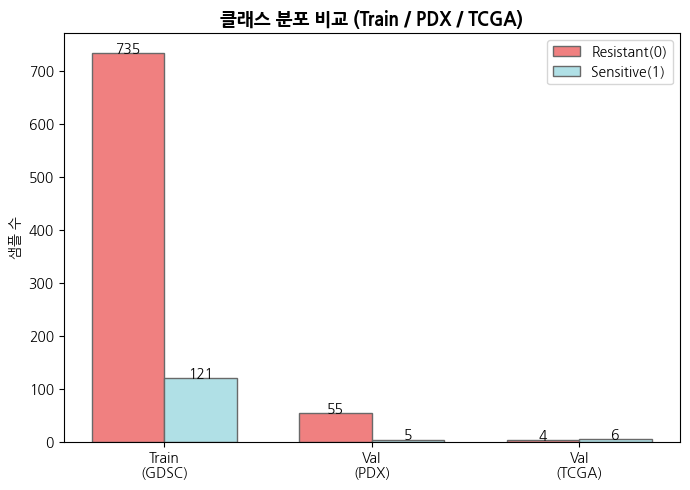

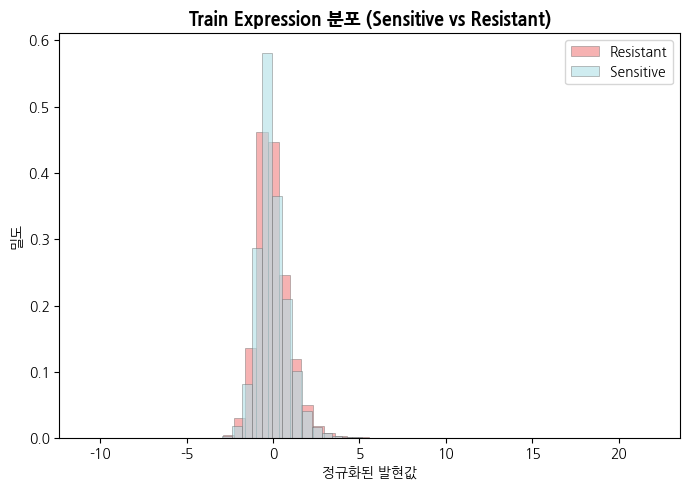

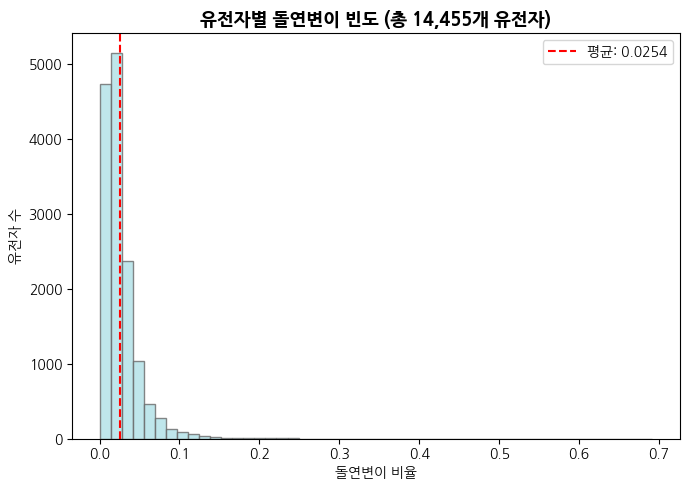

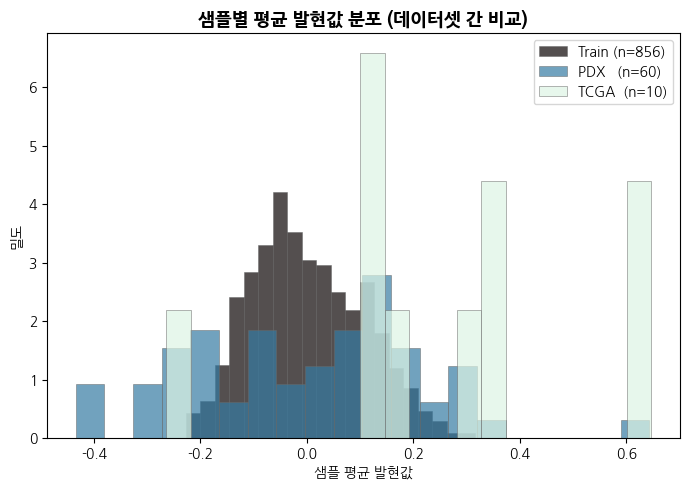

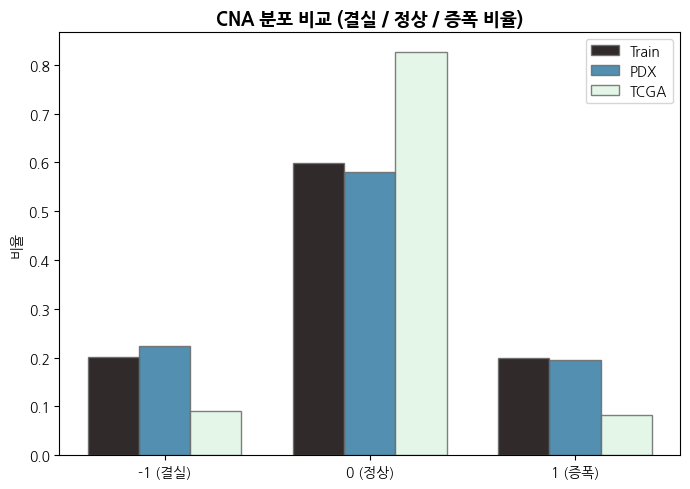

📌 데이터셋 요약
Train (GDSC) : 856샘플
  R:735 / S:121  (불균형 비율 1:6)

Val   (PDX)  : 60샘플
  R:55 / S:5

Val   (TCGA) : 10샘플  ← ⭐ 논문에 없는 추가 검증
  R:4 / S:6

입력 차원
  Expression : 18,232
  Mutation   : 14,455
  CNA        : 20,503

돌연변이 평균 빈도: 0.0254 (2.54%)


In [20]:
# ======================================================
# 5) EDA 시각화
# ======================================================

import matplotlib.cm as cm
mako = cm.get_cmap('mako', 3)
v_colors = [mako(0.1), mako(0.5), mako(0.9)]  # Train / PDX / TCGA

# 5-1) 클래스 분포 비교
fig, ax = plt.subplots(figsize=(7, 5))
datasets = {'Train\n(GDSC)': y_train_np,
            'Val\n(PDX)':    y_val_np,
            'Val\n(TCGA)':   y_tcga_np}
x = np.arange(len(datasets))
width = 0.35
r_counts = [int((v==0).sum()) for v in datasets.values()]
s_counts = [int((v==1).sum()) for v in datasets.values()]
bars_r = ax.bar(x - width/2, r_counts, width,
                label='Resistant(0)', color='#F08080', edgecolor='dimgray')
bars_s = ax.bar(x + width/2, s_counts, width,
                label='Sensitive(1)',  color='#B0E0E6', edgecolor='dimgray')
ax.set_xticks(x)
ax.set_xticklabels(datasets.keys())
ax.set_title('클래스 분포 비교 (Train / PDX / TCGA)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('샘플 수')
ax.legend()
for bar, cnt in zip(list(bars_r)+list(bars_s), r_counts+s_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(cnt), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('eda_01_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()


# 5-2) Train Expression 분포
fig, ax = plt.subplots(figsize=(7, 5))
sample_idx = np.random.choice(X_train_expr_scaled.shape[1], 500, replace=False)
r_vals = X_train_expr_scaled[y_train_np == 0][:, sample_idx].flatten()
s_vals = X_train_expr_scaled[y_train_np == 1][:, sample_idx].flatten()
ax.hist(r_vals, bins=50, alpha=0.6, color='#F08080',
        label='Resistant', density=True, edgecolor='dimgray', linewidth=0.5)
ax.hist(s_vals, bins=50, alpha=0.6, color='#B0E0E6',
        label='Sensitive',  density=True, edgecolor='dimgray', linewidth=0.5)
ax.set_title('Train Expression 분포 (Sensitive vs Resistant)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('정규화된 발현값')
ax.set_ylabel('밀도')
ax.legend()
plt.tight_layout()
plt.savefig('eda_02_expression_dist.png', dpi=150, bbox_inches='tight')
plt.show()


# 5-3) 유전자별 돌연변이 빈도
fig, ax = plt.subplots(figsize=(7, 5))
mut_rate = X_train_mut_np.mean(axis=0)
ax.hist(mut_rate, bins=50, color='#B0E0E6', alpha=0.8, edgecolor='dimgray')
ax.axvline(mut_rate.mean(), color='red', linestyle='--',
           label=f'평균: {mut_rate.mean():.4f}')
ax.set_title(f'유전자별 돌연변이 빈도 (총 {len(mut_rate):,}개 유전자)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('돌연변이 비율')
ax.set_ylabel('유전자 수')
ax.legend()
plt.tight_layout()
plt.savefig('eda_03_mutation_freq.png', dpi=150, bbox_inches='tight')
plt.show()


# 5-4) 샘플별 평균 발현값 분포
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(X_train_expr_scaled.mean(axis=1), bins=20, alpha=0.7,
        color=v_colors[0], label=f'Train (n={len(y_train_np)})', density=True, edgecolor='dimgray', linewidth=0.5)
ax.hist(X_val_expr_scaled.mean(axis=1),   bins=20, alpha=0.7,
        color=v_colors[1], label=f'PDX   (n={len(y_val_np)})',   density=True, edgecolor='dimgray', linewidth=0.5)
ax.hist(X_tcga_expr_scaled.mean(axis=1),  bins=20, alpha=0.7,
        color=v_colors[2], label=f'TCGA  (n={len(y_tcga_np)})',  density=True, edgecolor='dimgray', linewidth=0.5)
ax.set_title('샘플별 평균 발현값 분포 (데이터셋 간 비교)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('샘플 평균 발현값')
ax.set_ylabel('밀도')
ax.legend()
plt.tight_layout()
plt.savefig('eda_04_expr_dataset_compare.png', dpi=150, bbox_inches='tight')
plt.show()


# 5-5) CNA 분포 비교
fig, ax = plt.subplots(figsize=(7, 5))
cna_labels = ['-1 (결실)', '0 (정상)', '1 (증폭)']
train_cna_dist = [(X_train_cna_np == v).mean() for v in [-1, 0, 1]]
val_cna_dist   = [(X_val_cna_np   == v).mean() for v in [-1, 0, 1]]
tcga_cna_dist  = [(X_tcga_cna_np  == v).mean() for v in [-1, 0, 1]]
x = np.arange(3)
width = 0.25
ax.bar(x - width, train_cna_dist, width,
       label='Train', color=v_colors[0], alpha=0.85, edgecolor='dimgray')
ax.bar(x,          val_cna_dist,  width,
       label='PDX',   color=v_colors[1], alpha=0.85, edgecolor='dimgray')
ax.bar(x + width,  tcga_cna_dist, width,
       label='TCGA',  color=v_colors[2], alpha=0.85, edgecolor='dimgray')
ax.set_xticks(x)
ax.set_xticklabels(cna_labels)
ax.set_title('CNA 분포 비교 (결실 / 정상 / 증폭 비율)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('비율')
ax.legend()
plt.tight_layout()
plt.savefig('eda_05_cna_compare.png', dpi=150, bbox_inches='tight')
plt.show()


# 데이터셋 요약
print("=" * 45)
print("📌 데이터셋 요약")
print("=" * 45)
print(f"Train (GDSC) : {len(y_train_np)}샘플")
print(f"  R:{int((y_train_np==0).sum())} / S:{int((y_train_np==1).sum())}"
      f"  (불균형 비율 1:{int((y_train_np==0).sum())//int((y_train_np==1).sum())})")
print(f"\nVal   (PDX)  : {len(y_val_np)}샘플")
print(f"  R:{int((y_val_np==0).sum())} / S:{int((y_val_np==1).sum())}")
print(f"\nVal   (TCGA) : {len(y_tcga_np)}샘플  ← ⭐ 논문에 없는 추가 검증")
print(f"  R:{int((y_tcga_np==0).sum())} / S:{int((y_tcga_np==1).sum())}")
print(f"\n입력 차원")
print(f"  Expression : {X_train_expr_scaled.shape[1]:,}")
print(f"  Mutation   : {X_train_mut_np.shape[1]:,}")
print(f"  CNA        : {X_train_cna_np.shape[1]:,}")
print(f"\n돌연변이 평균 빈도: {mut_rate.mean():.4f} ({mut_rate.mean()*100:.2f}%)")
print("=" * 45)

In [21]:
# ======================================================
# 5) 모델에 넣기 전 결측치 & 중복 확인
# ======================================================

print("=" * 50)
print("TRAIN 데이터 품질 검사")
print("=" * 50)

# 결측치 확인
print("\n[결측치]")
print(f"  X_train_expr NaN: {np.isnan(X_train_expr_scaled).sum()}")
print(f"  X_train_mut  NaN: {np.isnan(X_train_mut_np).sum()}")
print(f"  X_train_cna  NaN: {np.isnan(X_train_cna_np).sum()}")
print(f"  y_train      NaN: {np.isnan(y_train_np).sum()}")

print(f"\n  X_val_expr   NaN: {np.isnan(X_val_expr_scaled).sum()}")
print(f"  X_val_mut    NaN: {np.isnan(X_val_mut_np).sum()}")
print(f"  X_val_cna    NaN: {np.isnan(X_val_cna_np).sum()}")
print(f"  y_val        NaN: {np.isnan(y_val_np).sum()}")

print(f"\n  X_tcga_expr NaN: {np.isnan(X_tcga_expr_scaled).sum()}")
print(f"  X_tcga_mut  NaN: {np.isnan(X_tcga_mut_np).sum()}")
print(f"  X_tcga_cna  NaN: {np.isnan(X_tcga_cna_np).sum()}")
print(f"  y_tcga      NaN: {np.isnan(y_tcga_np).sum()}")

# 중복 샘플 확인
print("\n[중복 샘플]")
print(f"  Train 전체: {len(train_common_samples)}개")
print(f"  Train 고유: {len(set(train_common_samples))}개")
print(f"  중복: {len(train_common_samples) - len(set(train_common_samples))}개")

print(f"\n  Val 전체: {len(val_common_samples)}개")
print(f"  Val 고유: {len(set(val_common_samples))}개")
print(f"  중복: {len(val_common_samples) - len(set(val_common_samples))}개")

print(f"\n  TCGA 전체: {len(valid_samples)}개")
print(f"  TCGA 고유: {len(set(valid_samples))}개")
print(f"  중복: {len(valid_samples) - len(set(valid_samples))}개")


# ======================================================
# 6) Train/Val 샘플 겹침 확인 (data leakage_강화 버전)
# ======================================================
print("\n[Data Leakage 검사]")

train_common = sorted(
    set(train_labels.index) & set(train_expr.columns)
    & set(train_mut.columns) & set(train_cna.columns)
)
val_common = sorted(
    set(val_labels.index) & set(val_expr.columns)
    & set(val_mut.columns) & set(val_cna.columns)
)

# (1) ID 기반 검사 (기본)
overlap_pdx  = set(train_common) & set(val_common)
overlap_tcga = set(train_common) & set(valid_samples)
print(f"  [ID 기반] Train-PDX  겹치는 샘플: {len(overlap_pdx)}개  "
      + ("✅ 없음" if not overlap_pdx  else f"⚠️ {overlap_pdx}"))
print(f"  [ID 기반] Train-TCGA 겹치는 샘플: {len(overlap_tcga)}개 "
      + ("✅ 없음" if not overlap_tcga else f"⚠️ {overlap_tcga}"))
print(f"  ※ 단, Train(숫자ID)과 PDX(X-xxxx)/TCGA(TCGA-xx)는 네이밍 규칙이 달라")
print(f"     ID 비교만으로는 충분하지 않음 → 발현 프로파일 상관관계로 추가 검증")

# (2) 발현 프로파일 상관관계 기반 검사
# Train 샘플별 평균 발현 벡터 (샘플 수가 많으므로 평균 사용)
train_expr_mean = X_train_expr_scaled.mean(axis=0)  # (n_genes,)

# PDX 각 샘플과 Train 전체 간 최대 Pearson 상관계수
print(f"\n  [상관관계 기반] PDX ↔ Train 발현 프로파일 유사도 검사")
from numpy.linalg import norm

def cosine_sim_batch(val_mat, train_mat, top_k=1):
    """val 각 샘플과 train 전체 간 코사인 유사도 최댓값 반환"""
    val_norm   = val_mat   / (norm(val_mat,   axis=1, keepdims=True) + 1e-8)
    train_norm = train_mat / (norm(train_mat, axis=1, keepdims=True) + 1e-8)
    sims = val_norm @ train_norm.T  # (n_val, n_train)
    return sims.max(axis=1)         # 각 val 샘플의 최대 유사도

pdx_max_sim  = cosine_sim_batch(X_val_expr_scaled,   X_train_expr_scaled)
tcga_max_sim = cosine_sim_batch(X_tcga_expr_scaled,  X_train_expr_scaled)

LEAKAGE_THRESHOLD = 0.99
pdx_suspicious  = np.where(pdx_max_sim  > LEAKAGE_THRESHOLD)[0]
tcga_suspicious = np.where(tcga_max_sim > LEAKAGE_THRESHOLD)[0]

print(f"  PDX  최대 유사도: {pdx_max_sim.max():.4f}  "
      + (f"⚠️ {len(pdx_suspicious)}개 의심 샘플" if len(pdx_suspicious) else "✅ 정상"))
print(f"  TCGA 최대 유사도: {tcga_max_sim.max():.4f}  "
      + (f"⚠️ {len(tcga_suspicious)}개 의심 샘플" if len(tcga_suspicious) else "✅ 정상"))
print(f"  (임계값: cosine similarity > {LEAKAGE_THRESHOLD})")


# ======================================================
# 7) 무분산 유전자 확인 (모든 샘플에서 값이 동일한 유전자)
# ======================================================

print("\n[무분산 유전자 (zero variance)]")
zero_var_expr = (X_train_expr_scaled.std(axis=0) == 0).sum()
zero_var_mut  = (X_train_mut_np.std(axis=0) == 0).sum()
zero_var_cna  = (X_train_cna_np.std(axis=0) == 0).sum()
print(f"  Expression: {zero_var_expr}개")
print(f"  Mutation  : {zero_var_mut}개  ← 모든 샘플이 동일값 → 정보 없음(삭제 필요)")
print(f"  CNA       : {zero_var_cna}개")

print("\n✅ 데이터 품질 검사 완료")

TRAIN 데이터 품질 검사

[결측치]
  X_train_expr NaN: 0
  X_train_mut  NaN: 0
  X_train_cna  NaN: 0
  y_train      NaN: 0

  X_val_expr   NaN: 0
  X_val_mut    NaN: 0
  X_val_cna    NaN: 0
  y_val        NaN: 0

  X_tcga_expr NaN: 0
  X_tcga_mut  NaN: 0
  X_tcga_cna  NaN: 0
  y_tcga      NaN: 0

[중복 샘플]
  Train 전체: 856개
  Train 고유: 856개
  중복: 0개

  Val 전체: 60개
  Val 고유: 60개
  중복: 0개

  TCGA 전체: 10개
  TCGA 고유: 10개
  중복: 0개

[Data Leakage 검사]
  [ID 기반] Train-PDX  겹치는 샘플: 0개  ✅ 없음
  [ID 기반] Train-TCGA 겹치는 샘플: 0개 ✅ 없음
  ※ 단, Train(숫자ID)과 PDX(X-xxxx)/TCGA(TCGA-xx)는 네이밍 규칙이 달라
     ID 비교만으로는 충분하지 않음 → 발현 프로파일 상관관계로 추가 검증

  [상관관계 기반] PDX ↔ Train 발현 프로파일 유사도 검사
  PDX  최대 유사도: 0.3995  ✅ 정상
  TCGA 최대 유사도: 0.3657  ✅ 정상
  (임계값: cosine similarity > 0.99)

[무분산 유전자 (zero variance)]
  Expression: 0개
  Mutation  : 17개  ← 모든 샘플이 동일값 → 정보 없음(삭제 필요)
  CNA       : 0개

✅ 데이터 품질 검사 완료


In [22]:
# ======================================================
# 8) 전처리 완료 데이터 저장
# ======================================================

# STEP 0: 저장 경로 지정
BASE_DIR = "/content/drive/MyDrive/AI Health care 실습파일/MOLI"
save_dir = os.path.join(BASE_DIR, "preprocessed")
os.makedirs(save_dir, exist_ok=True)
print(f"저장 경로: {save_dir}")

# STEP 1: 위에서 확인한 무분산 유전자 제거
if X_train_mut_np.shape[1] == 14455:
    zero_var_mask = X_train_mut_np.std(axis=0) != 0  # False인 17개 제거
    X_train_mut_np = X_train_mut_np[:, zero_var_mask]
    X_val_mut_np   = X_val_mut_np[:, zero_var_mask]
    X_tcga_mut_np = X_tcga_mut_np[:, zero_var_mask]
    print(f"Mutation 유전자: 14,455 → {X_train_mut_np.shape[1]}개 (17개 제거)")

else:
    print(f"이미 적용됨: {X_train_mut_np.shape[1]}개")

# STEP 2: numpy 배열로 저장(불러와서 바로 사용 가능)
np.save(f"{save_dir}/X_train_expr.npy", X_train_expr_scaled.astype(np.float32))
np.save(f"{save_dir}/X_train_mut.npy",  X_train_mut_np.astype(np.float32))
np.save(f"{save_dir}/X_train_cna.npy",  X_train_cna_np.astype(np.float32))
np.save(f"{save_dir}/y_train.npy",      y_train_np.astype(np.float32))

np.save(f"{save_dir}/X_val_expr.npy",   X_val_expr_scaled.astype(np.float32))
np.save(f"{save_dir}/X_val_mut.npy",    X_val_mut_np.astype(np.float32))
np.save(f"{save_dir}/X_val_cna.npy",    X_val_cna_np.astype(np.float32))
np.save(f"{save_dir}/y_val.npy",        y_val_np.astype(np.float32))

np.save(f"{save_dir}/X_tcga_expr.npy", X_tcga_expr_scaled.astype(np.float32))
np.save(f"{save_dir}/X_tcga_mut.npy",  X_tcga_mut_np.astype(np.float32))
np.save(f"{save_dir}/X_tcga_cna.npy",  X_tcga_cna_np.astype(np.float32))
np.save(f"{save_dir}/y_tcga.npy",      y_tcga_np.astype(np.float32))

# 저장 확인
print("\n✅ 저장 완료:")
for f in sorted(os.listdir(save_dir)):
    if not f.endswith('.npy'):
        continue
    path = os.path.join(save_dir, f)
    arr  = np.load(path)
    print(f"  {f:30s} shape: {str(arr.shape):20s} dtype: {arr.dtype}")

print(f"\n📌 최종 데이터셋 요약:")
print(f"  Train (GDSC) : 856샘플")
print(f"  Val   (PDX)  : 60샘플")
print(f"  Val   (TCGA) : {len(valid_samples)}샘플  ← 논문에 없는 추가 검증 ⭐")

저장 경로: /content/drive/MyDrive/AI Health care 실습파일/MOLI/preprocessed
Mutation 유전자: 14,455 → 14438개 (17개 제거)

✅ 저장 완료:
  X_tcga_cna.npy                 shape: (10, 20503)          dtype: float32
  X_tcga_expr.npy                shape: (10, 18232)          dtype: float32
  X_tcga_mut.npy                 shape: (10, 14438)          dtype: float32
  X_train_cna.npy                shape: (856, 20503)         dtype: float32
  X_train_expr.npy               shape: (856, 18232)         dtype: float32
  X_train_mut.npy                shape: (856, 14438)         dtype: float32
  X_val_cna.npy                  shape: (60, 20503)          dtype: float32
  X_val_expr.npy                 shape: (60, 18232)          dtype: float32
  X_val_mut.npy                  shape: (60, 14438)          dtype: float32
  y_tcga.npy                     shape: (10,)                dtype: float32
  y_train.npy                    shape: (856,)               dtype: float32
  y_val.npy                      shape: (60,)  

In [23]:
# ======================================================
# 9) scaler, zero_var_mask 저장
# ======================================================

import pickle

with open(f"{save_dir}/scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)

np.save(f"{save_dir}/zero_var_mask.npy", zero_var_mask)

print("✅ scaler.pkl 저장 완료")
print("✅ zero_var_mask.npy 저장 완료")

# ======================================================
# 10) 전처리 메타데이터 저장
# ======================================================
meta = {
    'drug'            : 'Cetuximab',
    'train_samples'   : int(len(y_train_np)),
    'val_pdx_samples' : int(len(y_val_np)),
    'val_tcga_samples': int(len(y_tcga_np)),
    'input_dim_expr'  : int(X_train_expr_scaled.shape[1]),
    'input_dim_mut'   : int(X_train_mut_np.shape[1]),
    'input_dim_cna'   : int(X_train_cna_np.shape[1]),
    'zero_var_removed': 17,
    'tcga_padded_expr': 18232 - 18114,
    'tcga_padded_mut' : 14455 - 12633,
    'tcga_padded_cna' : 20503 - 20432,
}
import json
with open(f"{save_dir}/meta.json", 'w') as f:
    json.dump(meta, f, indent=2)
print("✅ meta.json 저장 완료")

✅ scaler.pkl 저장 완료
✅ zero_var_mask.npy 저장 완료
✅ meta.json 저장 완료
